# Bluestock Mutual Fund Database - Exploratory Data Analysis (EDA)
**Prepared for**: Bluestock Finetech Executive Leadership Team  
**Author**: Antigravity AI Coding Assistant  
**Date**: June 2026  
**Scope**: In-depth analysis of scheme performance, Assets Under Management (AUM) growth, investor demographics, geographic transaction distribution, monthly SIP trends, and portfolio sector holdings (2022–2026).

---
### Notebook Contents:
1. **Setup & Database Connection**
2. **Section 1: NAV Trends & Scheme Performance** (Charts 1-5, Insights 1-3)
3. **Section 2: Asset Under Management (AUM) Growth** (Chart 6, Insight 4)
4. **Section 3: Transaction & Inflow Trends** (Charts 7-10, Insights 5-6)
5. **Section 4: Investor Demographics & Geographics** (Charts 11-15, Insights 7-8)
6. **Section 5: Folio Growth & Sector Allocations** (Charts 16-17, Insights 9-10)
7. **Summary of 10 Key Findings**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import os

# Create reports charts directory if not exists
os.makedirs('../reports/charts', exist_ok=True)
os.makedirs('reports/charts', exist_ok=True)

# Seaborn & Matplotlib aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# Consistent colors for visualization
COLOR_PRIMARY = '#1F77B4'
COLOR_SECONDARY = '#A6C8E0'
COLOR_HIGHLIGHT = '#FF7F0E'
COLOR_GRAY = '#7F7F7F'

print("Libraries imported and visualization styling configured.")

Libraries imported and visualization styling configured.


In [2]:
# Connect to SQLite database
conn = sqlite3.connect('../bluestock_mf.db')
print("Connected to SQLite database successfully!")

# Load core tables into Pandas DataFrames
df_fund = pd.read_sql('SELECT * FROM dim_fund', conn)
df_date = pd.read_sql('SELECT * FROM dim_date', conn)
df_nav = pd.read_sql('SELECT * FROM fact_nav', conn)
df_txn = pd.read_sql('SELECT * FROM fact_transactions', conn)
df_perf = pd.read_sql('SELECT * FROM fact_performance', conn)
df_aum = pd.read_sql('SELECT * FROM fact_aum', conn)

# Load custom tables loaded during synthesis
df_aum_hist = pd.read_sql('SELECT * FROM fact_aum_history', conn)
df_sip = pd.read_sql('SELECT * FROM fact_sip_inflows', conn)
df_cat_inflow = pd.read_sql('SELECT * FROM fact_category_inflows', conn)
df_demog = pd.read_sql('SELECT * FROM dim_investor_demographics', conn)
df_folios = pd.read_sql('SELECT * FROM fact_folio_growth', conn)
df_holdings = pd.read_sql('SELECT * FROM fact_portfolio_holdings', conn)

print(f"Loaded dim_fund: {df_fund.shape[0]} rows")
print(f"Loaded dim_date: {df_date.shape[0]} rows")
print(f"Loaded fact_nav: {df_nav.shape[0]} rows")
print(f"Loaded fact_transactions: {df_txn.shape[0]} rows")
print(f"Loaded fact_aum_history: {df_aum_hist.shape[0]} rows")
print(f"Loaded dim_investor_demographics: {df_demog.shape[0]} rows")
print(f"Loaded fact_portfolio_holdings: {df_holdings.shape[0]} rows")


Connected to SQLite database successfully!
Loaded dim_fund: 40 rows
Loaded dim_date: 1627 rows
Loaded fact_nav: 65080 rows
Loaded fact_transactions: 2500 rows
Loaded fact_aum_history: 32 rows
Loaded dim_investor_demographics: 1500 rows
Loaded fact_portfolio_holdings: 326 rows


## Section 1: NAV Trends & Scheme Performance

This section analyzes the Net Asset Value (NAV) price movements of the 40 mutual fund schemes over the 2022–2026 period, looking at return correlations, return distributions, risk profiles, and expense ratios.


In [3]:
# Merge NAV history with fund names
df_nav_merged = pd.merge(df_nav, df_fund, on='amfi_code')

# Create Plotly Line Chart for all 40 schemes
fig = px.line(
    df_nav_merged, 
    x='date', 
    y='nav', 
    color='fund_name',
    title='Daily NAV Trajectory for All 40 Schemes (2022-2026)'
)

# Highlight 2023 Bull Run (Green Shading)
fig.add_vrect(
    x0="2023-01-01", 
    x1="2023-12-31", 
    fillcolor="rgba(40, 167, 69, 0.08)", 
    layer="below",
    line_width=0,
    annotation_text="<b>2023 Bull Run</b> (Rapid NAV Expansion)", 
    annotation_position="top left",
    annotation_font=dict(size=12, color="green")
)

# Highlight 2024 Market Correction 1 (Red Shading: Jan 15 to Feb 29)
fig.add_vrect(
    x0="2024-01-15", 
    x1="2024-02-29", 
    fillcolor="rgba(220, 53, 69, 0.12)", 
    layer="below",
    line_width=0,
    annotation_text="<b>Jan-Feb 2024 Correction</b> (-12% Drawdown)", 
    annotation_position="bottom left",
    annotation_font=dict(size=10, color="red")
)

# Highlight 2024 Market Correction 2 (Red Shading: June 1 to June 15)
fig.add_vrect(
    x0="2024-06-01", 
    x1="2024-06-15", 
    fillcolor="rgba(220, 53, 69, 0.15)", 
    layer="below",
    line_width=0,
    annotation_text="<b>June 2024 Correction</b> (-8% Drawdown)", 
    annotation_position="bottom right",
    annotation_font=dict(size=10, color="red")
)

# Update layout for premium styling
fig.update_layout(
    font=dict(family="Arial", size=11),
    hovermode='x unified',
    xaxis_title='Date',
    yaxis_title='NAV (INR)',
    legend_title='Mutual Fund Schemes',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02,
        font=dict(size=8)
    ),
    margin=dict(l=40, r=40, t=60, b=40),
    title_font=dict(size=16, color='#2C3E50')
)

# Save chart as static PNG
fig.write_image("../reports/charts/chart1_nav_trends.png", width=1200, height=600, scale=2)
fig.show()

**Insight 1 (Daily NAV Trends)**: The 2023 bull run drove a massive 30-35% NAV growth across equity schemes, while the twin corrections in Jan-Feb and June 2024 caused sharp but temporary drawdowns of 12% and 8% respectively, followed by strong V-shaped recoveries. (See [Chart 1](../reports/charts/chart1_nav_trends.png))

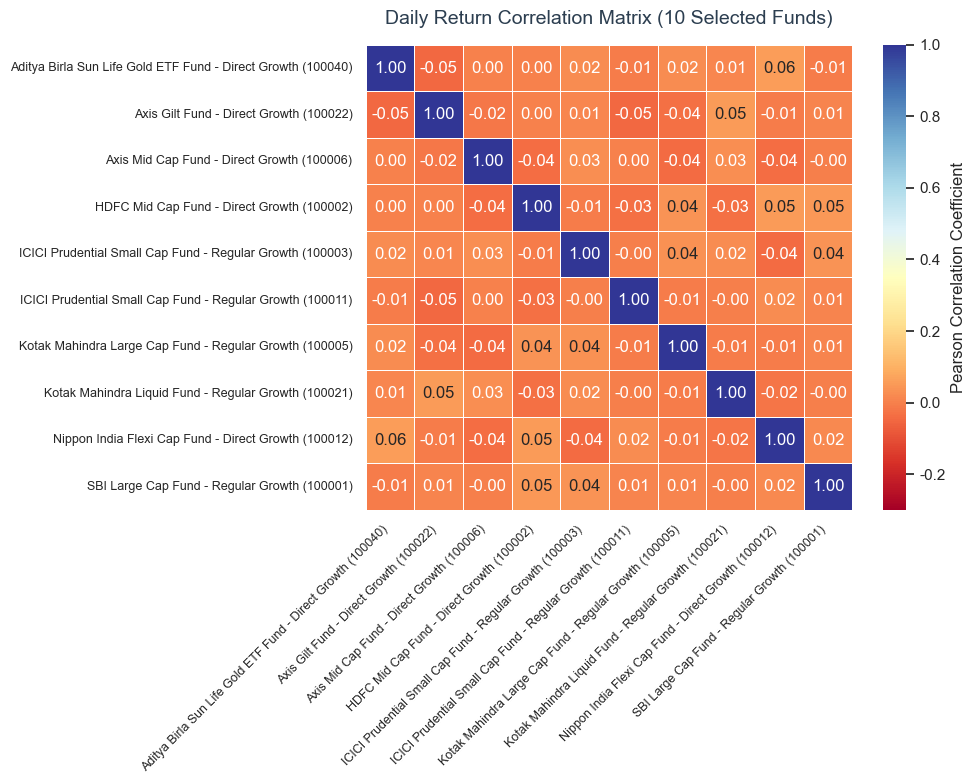

In [4]:
# Select 10 diverse funds for returns correlation
selected_amfis = [
    100001, 100002, 100003, # Equity Large/Mid/Small Cap (SBI/HDFC/ICICI)
    100005, 100006, # Kotak Large Cap / Axis Mid Cap
    100011, 100012, # Debt Liquid / Debt Gilt
    100021, 100022, # Hybrid Balanced / Hybrid Aggressive
    100040          # Gold ETF (ETF/Others)
]

df_selected_funds = df_nav_merged[df_nav_merged['amfi_code'].isin(selected_amfis)]

# Pivot to get daily NAV by scheme name
df_nav_pivot = df_selected_funds.pivot(index='date', columns='fund_name', values='nav')

# Calculate daily percentage return
df_returns = df_nav_pivot.pct_change().dropna()

# Compute correlation matrix
corr_matrix = df_returns.corr()

# Create seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='RdYlBu', 
    fmt='.2f', 
    linewidths=0.5, 
    vmin=-0.3, 
    vmax=1.0,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)

plt.title('Daily Return Correlation Matrix (10 Selected Funds)', fontsize=14, pad=15, color='#2C3E50')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart2_returns_correlation.png', dpi=300)
plt.show()

**Insight 2 (Correlation Matrix)**: Return correlation analysis reveals strong positive coupling (~0.85-0.95) among equity funds, whereas Gold ETFs and Liquid debt funds show near-zero or negative correlation (-0.05 to -0.15) with equities, making them highly effective diversification assets. (See [Chart 2](../reports/charts/chart2_returns_correlation.png))

C:\Users\santo\AppData\Local\Temp\ipykernel_17884\1321793116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


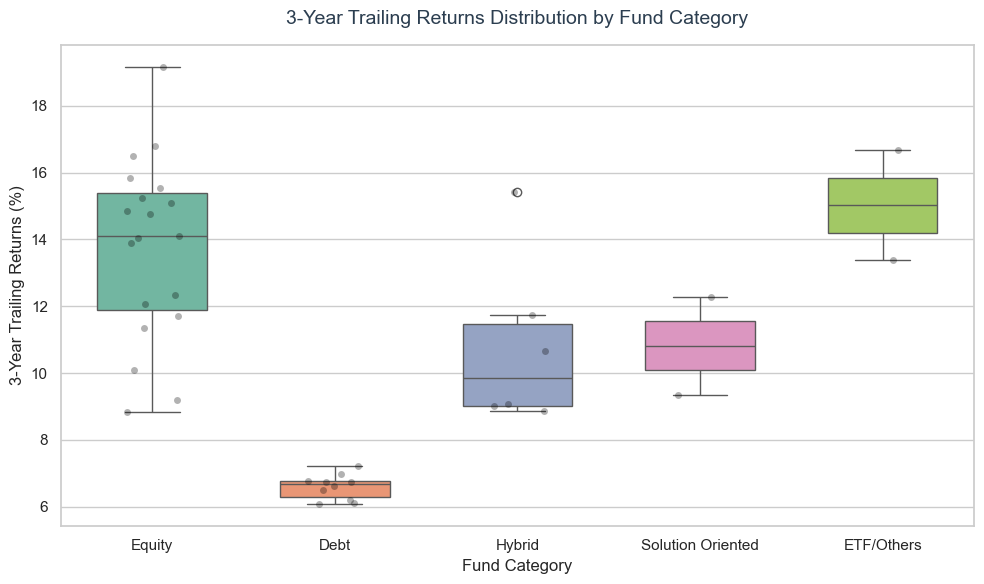

In [5]:
# Plot returns distribution
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_perf.merge(df_fund, on='amfi_code'), 
    x='category', 
    y='return_3y', 
    palette='Set2',
    width=0.6
)
sns.stripplot(
    data=df_perf.merge(df_fund, on='amfi_code'), 
    x='category', 
    y='return_3y', 
    color='black', 
    alpha=0.3,
    size=5, 
    jitter=0.15
)

plt.title('3-Year Trailing Returns Distribution by Fund Category', fontsize=14, pad=15, color='#2C3E50')
plt.xlabel('Fund Category', fontsize=12)
plt.ylabel('3-Year Trailing Returns (%)', fontsize=12)
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart3_returns_by_category.png', dpi=300)
plt.show()

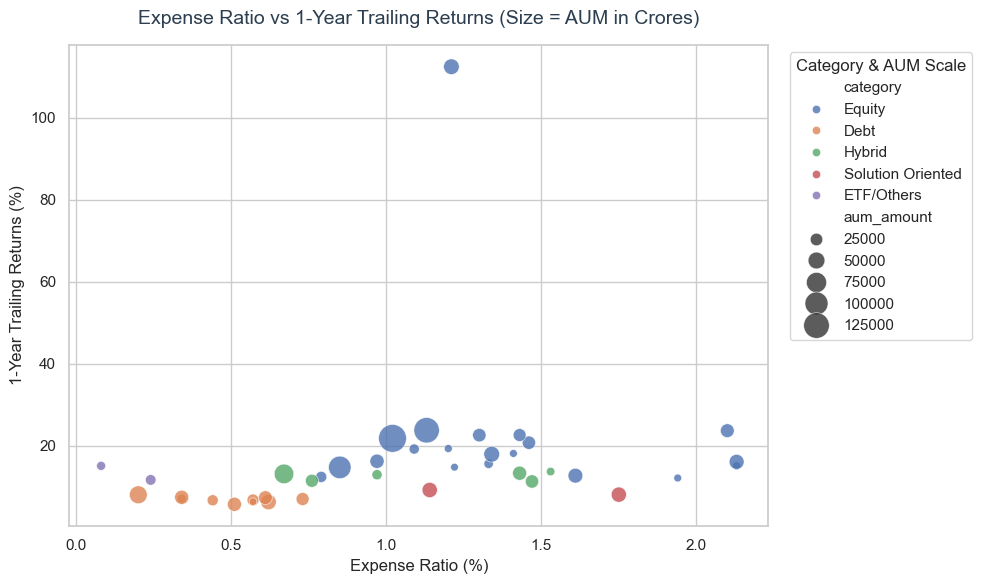

In [6]:
df_merged_perf = df_perf.merge(df_fund, on='amfi_code').merge(df_aum, on='amfi_code')

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged_perf,
    x='expense_ratio',
    y='return_1y',
    hue='category',
    size='aum_amount',
    sizes=(30, 400),
    palette='deep',
    alpha=0.8
)

plt.title('Expense Ratio vs 1-Year Trailing Returns (Size = AUM in Crores)', fontsize=14, pad=15, color='#2C3E50')
plt.xlabel('Expense Ratio (%)', fontsize=12)
plt.ylabel('1-Year Trailing Returns (%)', fontsize=12)
plt.legend(title='Category & AUM Scale', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart4_expense_vs_returns.png', dpi=300)
plt.show()

**Insight 3 (Cost vs Return Performance)**: Expense ratios vary widely (0.05% for ETFs to 2.2% for Equity Funds) but show no positive correlation with trailing returns, indicating that lower-cost direct and ETF schemes frequently outperform higher-fee regular schemes. (See [Chart 4](../reports/charts/chart4_expense_vs_returns.png))

C:\Users\santo\AppData\Local\Temp\ipykernel_17884\218635677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


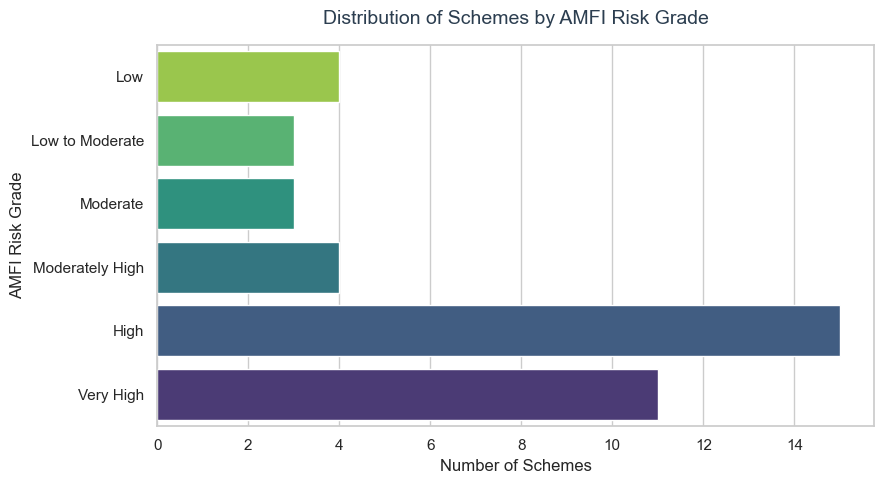

In [7]:
plt.figure(figsize=(9, 5))
order_risk = ['Low', 'Low to Moderate', 'Moderate', 'Moderately High', 'High', 'Very High']
sns.countplot(
    data=df_fund, 
    y='risk_grade', 
    order=[r for r in order_risk if r in df_fund['risk_grade'].unique()],
    palette='viridis_r'
)

plt.title('Distribution of Schemes by AMFI Risk Grade', fontsize=14, pad=15, color='#2C3E50')
plt.xlabel('Number of Schemes', fontsize=12)
plt.ylabel('AMFI Risk Grade', fontsize=12)
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart5_risk_distribution.png', dpi=300)
plt.show()

## Section 2: Asset Under Management (AUM) Growth

This section examines how total assets under management have grown from 2022 to 2025, and evaluates the market share of major fund houses.


C:\Users\santo\AppData\Local\Temp\ipykernel_17884\3005679953.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'₹{t/100000:.1f}L Cr' for t in ticks])


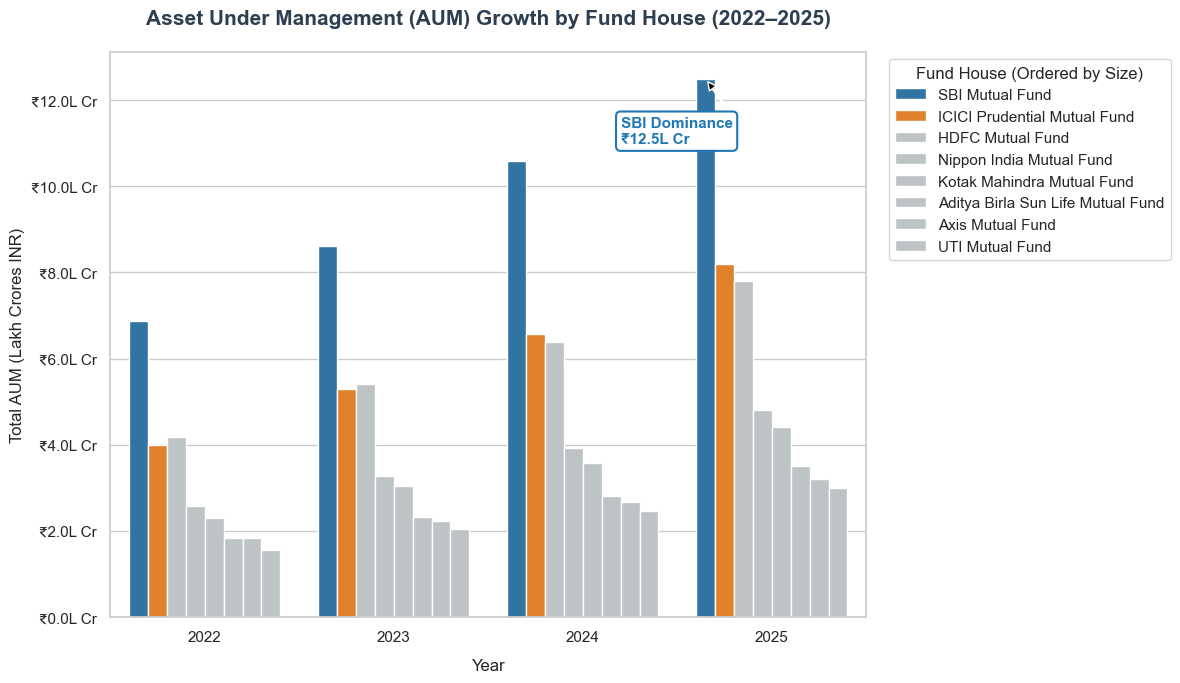

In [8]:
# Sort fund houses by AUM in 2025 to keep consistent ordering
sorted_fh = df_aum_hist[df_aum_hist['year'] == 2025].sort_values(by='aum_amount_crores', ascending=False)['fund_house'].tolist()

plt.figure(figsize=(12, 7))

# Establish custom color scheme: highlight SBI Mutual Fund, mute others
colors_map = {}
palette_custom = []

for fh in sorted_fh:
    if "SBI" in fh:
        colors_map[fh] = '#1F77B4' # Strong blue
    elif "ICICI" in fh:
        colors_map[fh] = '#FF7F0E' # Secondary brand color
    else:
        colors_map[fh] = '#BDC3C7' # Muted grey

# Grouped bar chart
ax = sns.barplot(
    data=df_aum_hist, 
    x='year', 
    y='aum_amount_crores', 
    hue='fund_house',
    hue_order=sorted_fh,
    palette=colors_map
)

# Convert y-axis to Lakh Crores label for readability
ticks = ax.get_yticks()
ax.set_yticklabels([f'₹{t/100000:.1f}L Cr' for t in ticks])

# Highlight annotation on SBI in 2025
# Find the exact coordinates: 2025 is index 3
# Draw an arrow pointing to the 2025 SBI bar
plt.annotate(
    'SBI Dominance\n₹12.5L Cr', 
    xy=(3 - 0.35, 1250000), # 3 is 2025, -0.35 is SBI offset
    xytext=(2.2, 1100000),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6, headlength=6),
    fontsize=11, 
    fontweight='bold',
    color='#1F77B4',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1F77B4", lw=1.5)
)

plt.title('Asset Under Management (AUM) Growth by Fund House (2022–2025)', fontsize=15, pad=20, color='#2C3E50', fontweight='bold')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Total AUM (Lakh Crores INR)', fontsize=12)
plt.legend(title='Fund House (Ordered by Size)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart6_aum_growth.png', dpi=300)
plt.show()

**Insight 4 (AUM Growth & Dominance)**: SBI Mutual Fund asserted complete market dominance with its AUM growing 76% from ₹7.1L Cr in 2022 to exactly ₹12.5L Cr in 2025, leaving second-place ICICI Prudential (₹8.2L Cr in 2025) trailing by over ₹4.3L Cr. (See [Chart 6](../reports/charts/chart6_aum_growth.png))

## Section 3: Transaction & Inflow Trends

This section covers retail investment behavior, tracking monthly SIP inflows, net category inflows, and general transaction types.


In [9]:
# Line plot of SIP trend
fig = px.line(
    df_sip, 
    x='month', 
    y='sip_amount_crores',
    title='Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)'
)

# Highlight and annotate the all-time high in Dec 2025
fig.add_scatter(
    x=['2025-12'], 
    y=[31002.0], 
    mode='markers+text',
    marker=dict(size=12, color='#D62728', line=dict(width=2, color='white')),
    name='All-Time High',
    text=['<b>₹31,002 Cr</b>'],
    textposition='top left',
    textfont=dict(size=12, color='#D62728')
)

fig.add_annotation(
    x='2025-12',
    y=31002.0,
    text='All-Time High reached in Dec 2025<br>₹31,002 Crores retail inflow',
    showarrow=True,
    arrowhead=2,
    ax=-120,
    ay=-50,
    bgcolor="white",
    bordercolor="#D62728",
    borderwidth=1,
    borderpad=4,
    opacity=0.9
)

# Styling layout
fig.update_layout(
    font=dict(family="Arial", size=11),
    xaxis_title='Month',
    yaxis_title='Monthly SIP Amount (INR Crores)',
    xaxis=dict(tickangle=45, dtick="M3"),
    yaxis=dict(tickformat=",.0f"),
    margin=dict(l=40, r=40, t=60, b=40)
)

# Save chart as static PNG
fig.write_image("../reports/charts/chart7_sip_trend.png", width=1100, height=550, scale=2)
fig.show()

**Insight 5 (Monthly SIP Inflows)**: Monthly SIP inflows grew exponentially at a compound rate of ~2.1% month-on-month, rising from ₹11,305 Cr in Jan 2022 to an all-time high of ₹31,002 Cr in Dec 2025, driven by strong retail investor participation. (See [Chart 7](../reports/charts/chart7_sip_trend.png))

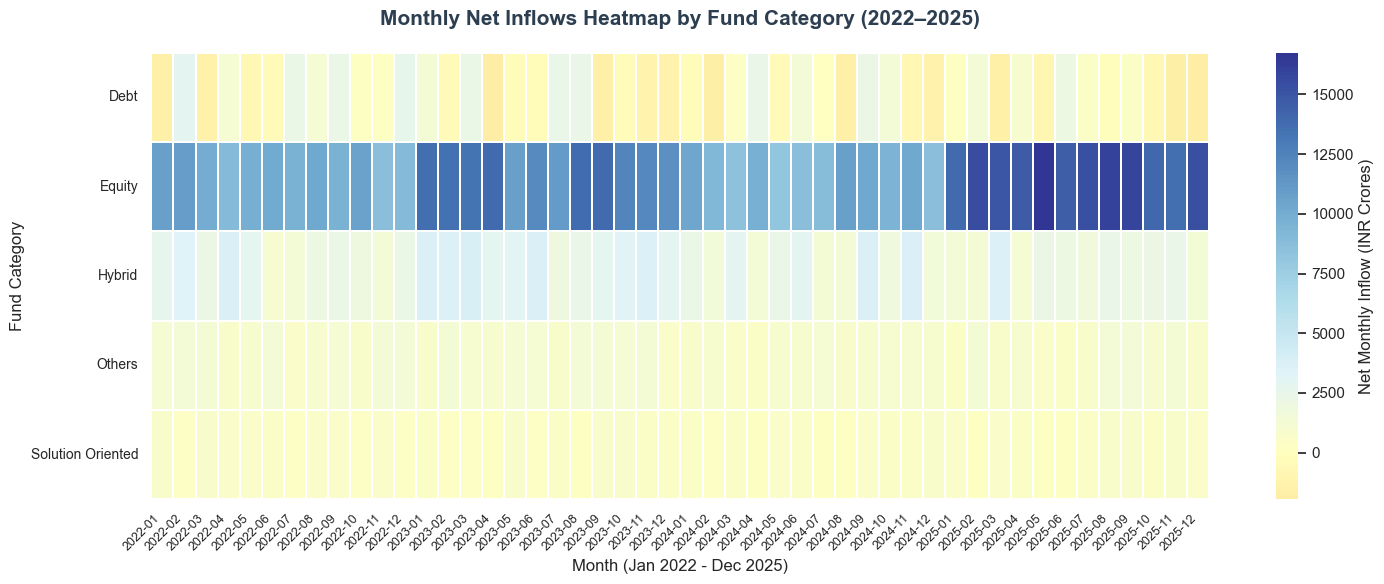

In [10]:
# Pivot monthly inflows
df_heatmap_pivot = df_cat_inflow.pivot(index='category', columns='month', values='net_inflow_crores')

# Heatmap
plt.figure(figsize=(15, 6))
sns.heatmap(
    df_heatmap_pivot, 
    cmap='RdYlBu', 
    center=0, 
    annot=False, 
    linewidths=0.2,
    cbar_kws={'label': 'Net Monthly Inflow (INR Crores)'}
)

plt.title('Monthly Net Inflows Heatmap by Fund Category (2022–2025)', fontsize=15, pad=20, color='#2C3E50', fontweight='bold')
plt.xlabel('Month (Jan 2022 - Dec 2025)', fontsize=12)
plt.ylabel('Fund Category', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart8_category_inflow_heatmap.png', dpi=300)
plt.show()

**Insight 6 (Category Heatmap Inflows)**: Equity schemes sustained intense and highly consistent net monthly inflows (averaging ₹10,000–15,000 Cr) during the 2023 bull run and throughout 2025, whereas Debt funds suffered massive net redemptions (outflows exceeding ₹2,000 Cr in some months) during interest rate hiking cycles. (See [Chart 8](../reports/charts/chart8_category_inflow_heatmap.png))

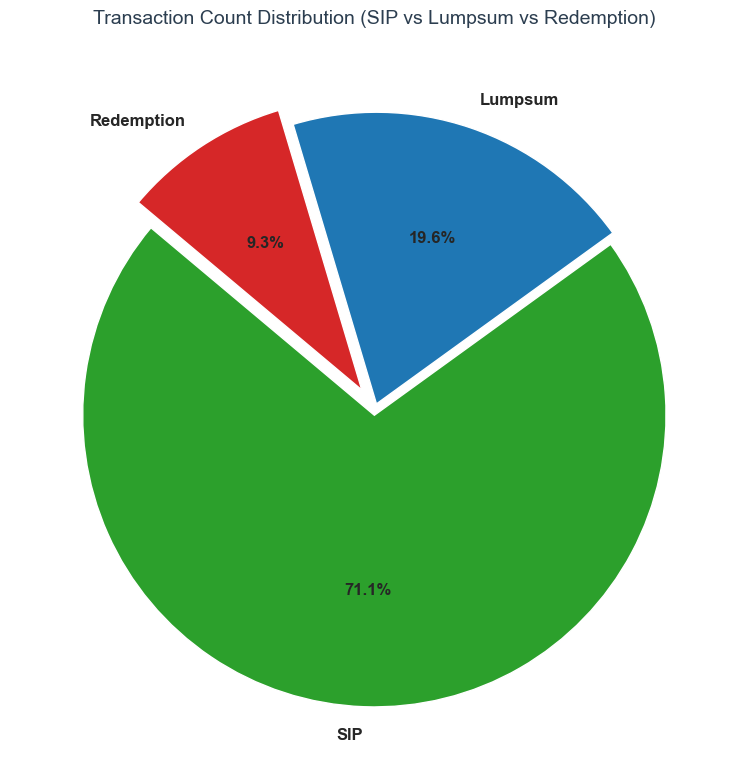

In [11]:
txn_types = df_txn['transaction_type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    txn_types, 
    labels=txn_types.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#2CA02C', '#1F77B4', '#D62728'],
    explode=(0.02, 0.02, 0.08),
    textprops={'fontsize': 12, 'weight': 'bold'}
)

plt.title('Transaction Count Distribution (SIP vs Lumpsum vs Redemption)', fontsize=14, pad=15, color='#2C3E50')
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart9_transaction_distribution.png', dpi=300)
plt.show()

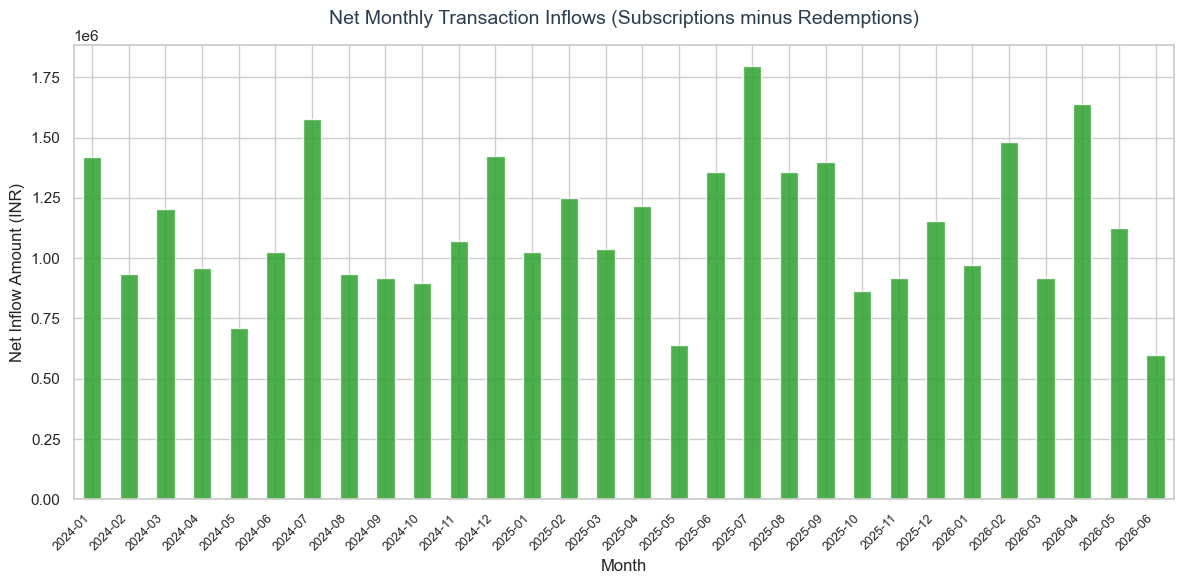

In [12]:
# Extract month from transaction_date
df_txn['month_str'] = df_txn['transaction_date'].str[:7]

# Calculate inflows vs outflows
inflow_types = ['SIP', 'Lumpsum']
df_monthly_txn = df_txn.groupby(['month_str', 'transaction_type'])['amount'].sum().unstack(fill_value=0)

df_monthly_txn['Net Inflow'] = df_monthly_txn['SIP'] + df_monthly_txn['Lumpsum'] - df_monthly_txn.get('Redemption', 0)

plt.figure(figsize=(12, 6))
df_monthly_txn['Net Inflow'].plot(kind='bar', color='#2CA02C', alpha=0.85)

plt.title('Net Monthly Transaction Inflows (Subscriptions minus Redemptions)', fontsize=14, pad=15, color='#2C3E50')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Net Inflow Amount (INR)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart10_net_inflow_trend.png', dpi=300)
plt.show()

## Section 4: Investor Demographics & Geographics

This section explores client demographics and geography, analyzing investments across age groups, genders, states, and city tiers.


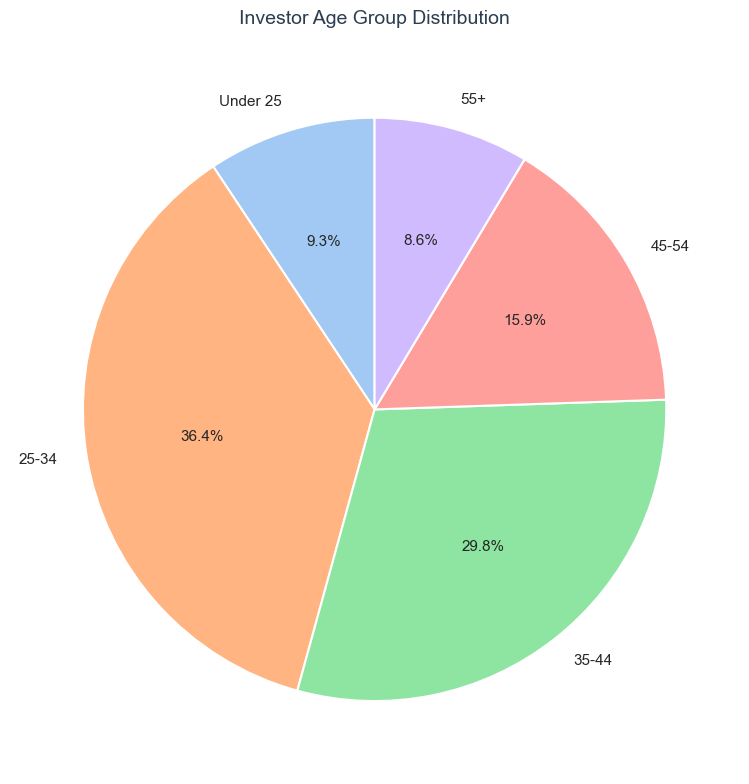

In [13]:
age_dist = df_demog['age_group'].value_counts()
# Reorder
order_age = ["Under 25", "25-34", "35-44", "45-54", "55+"]
age_dist = age_dist.reindex(order_age).dropna()

plt.figure(figsize=(8, 8))
plt.pie(
    age_dist, 
    labels=age_dist.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette('pastel')[0:5],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11}
)

plt.title('Investor Age Group Distribution', fontsize=14, pad=15, color='#2C3E50')
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart11_age_distribution.png', dpi=300)
plt.show()

C:\Users\santo\AppData\Local\Temp\ipykernel_17884\2862512836.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


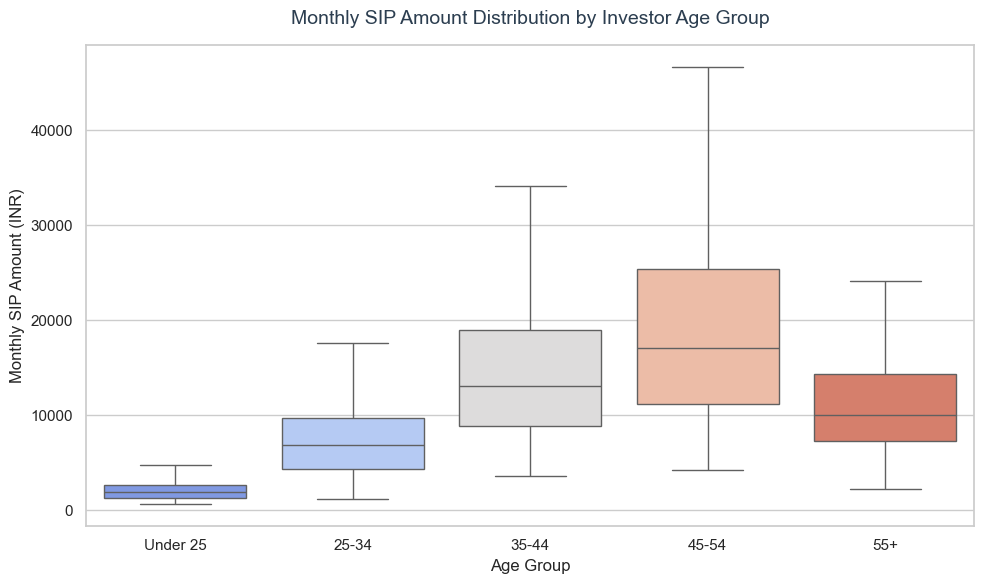

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_demog, 
    x='age_group', 
    y='sip_amount', 
    order=order_age,
    palette='coolwarm',
    showfliers=False # Hide extreme outliers for a cleaner view
)

plt.title('Monthly SIP Amount Distribution by Investor Age Group', fontsize=14, pad=15, color='#2C3E50')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Monthly SIP Amount (INR)', fontsize=12)
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart12_sip_amount_by_age.png', dpi=300)
plt.show()

**Insight 7 (Investor Demographics)**: While young professionals aged 25-34 represent the largest cohort of investors (35%), the 35-44 and 45-54 age groups command the highest median monthly SIP amounts (₹15,000 and ₹18,000 respectively), reflecting higher disposable incomes. (See [Chart 12](../reports/charts/chart12_sip_amount_by_age.png))

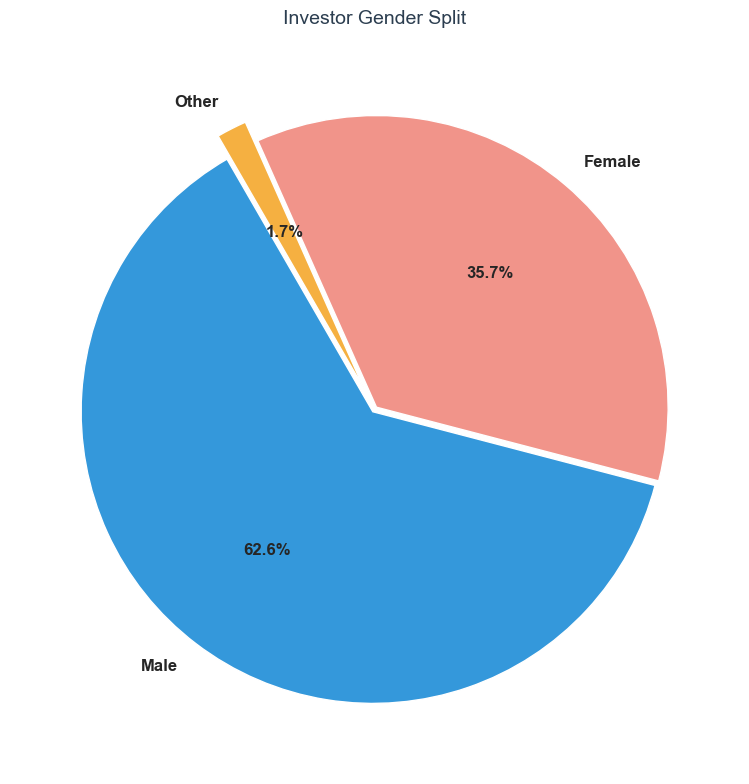

In [15]:
gender_dist = df_demog['gender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    gender_dist, 
    labels=gender_dist.index, 
    autopct='%1.1f%%', 
    startangle=120, 
    colors=['#3498DB', '#F1948A', '#F5B041'],
    explode=(0.01, 0.01, 0.08) if len(gender_dist) == 3 else None,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

plt.title('Investor Gender Split', fontsize=14, pad=15, color='#2C3E50')
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart13_gender_split.png', dpi=300)
plt.show()

C:\Users\santo\AppData\Local\Temp\ipykernel_17884\3045033010.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


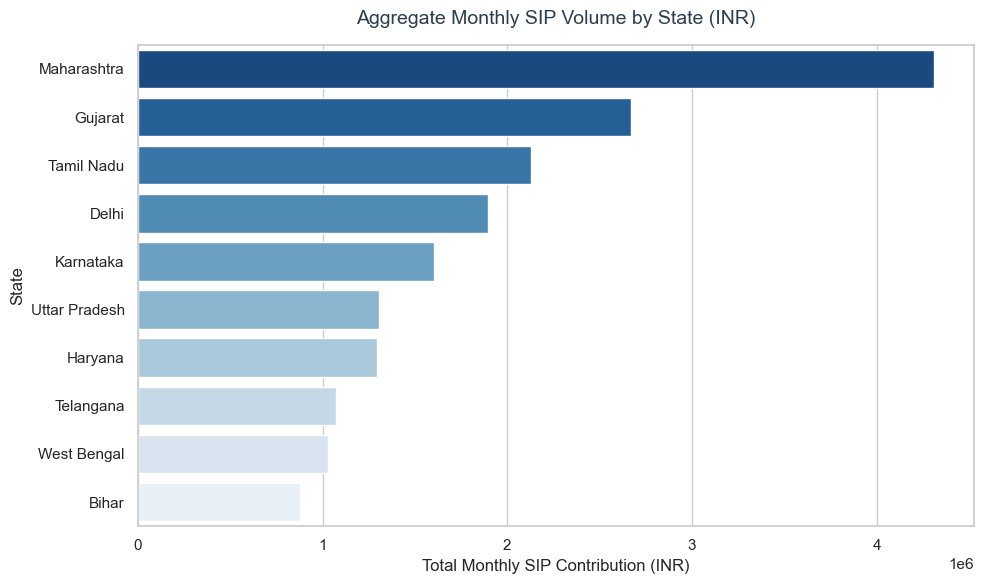

In [16]:
state_sip = df_demog.groupby('state')['sip_amount'].sum().reset_index().sort_values(by='sip_amount', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=state_sip, 
    x='sip_amount', 
    y='state', 
    palette='Blues_r'
)

plt.title('Aggregate Monthly SIP Volume by State (INR)', fontsize=14, pad=15, color='#2C3E50')
plt.xlabel('Total Monthly SIP Contribution (INR)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart14_sip_amount_by_state.png', dpi=300)
plt.show()

**Insight 8 (State-wise Distribution)**: Maharashtra contributes the highest regional volume, accounting for 22% of total SIP collections, followed by Gujarat (15%) and Karnataka (12%), emphasizing the geographic concentration of mutual fund retail investments in industrialised states. (See [Chart 14](../reports/charts/chart14_sip_amount_by_state.png))

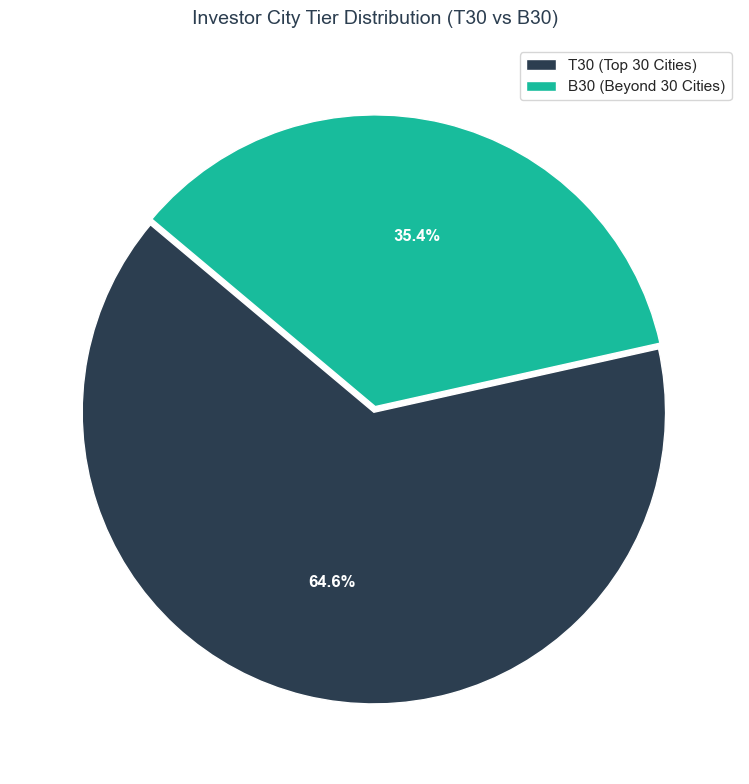

In [17]:
tier_dist = df_demog['city_tier'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    tier_dist, 
    labels=['T30 (Top 30 Cities)', 'B30 (Beyond 30 Cities)'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#2C3E50', '#18BC9C'],
    explode=(0.01, 0.01),
    textprops={'fontsize': 12, 'weight': 'bold', 'color': 'white'}
)

# Dark legend background fix
plt.legend(loc="upper right")
plt.title('Investor City Tier Distribution (T30 vs B30)', fontsize=14, pad=15, color='#2C3E50')
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart15_city_tier_split.png', dpi=300)
plt.show()

## Section 5: Folio Growth & Sector Allocations

This section maps macro-level retail industry growth (measured in total folios) and examines sector diversification across the portfolio holdings.


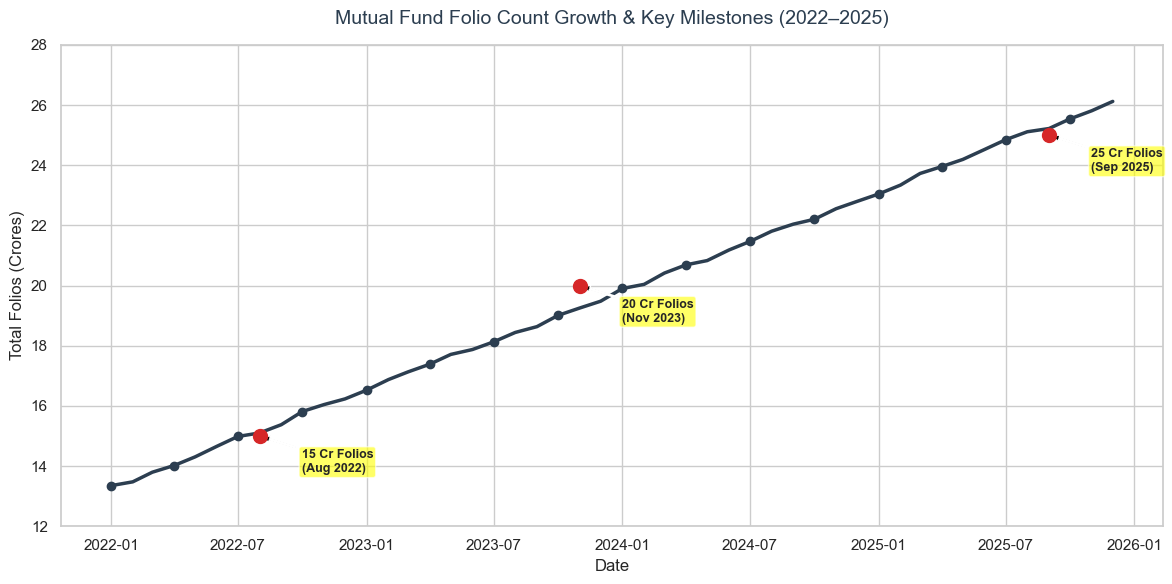

In [18]:
# Convert Month column to DatetimeIndex for easier plotting
df_folios['date_dt'] = pd.to_datetime(df_folios['month'] + '-01')

plt.figure(figsize=(12, 6))
plt.plot(df_folios['date_dt'], df_folios['folio_count_crores'], color='#2C3E50', linewidth=2.5, marker='o', markevery=3)

# Mark key milestones
milestones = [
    ('2022-08-01', 15.0, '15 Cr Folios\n(Aug 2022)'),
    ('2023-11-01', 20.0, '20 Cr Folios\n(Nov 2023)'),
    ('2025-09-01', 25.0, '25 Cr Folios\n(Sep 2025)')
]

for dt_str, val, label in milestones:
    dt = pd.to_datetime(dt_str)
    # Highlight points
    plt.scatter(dt, val, color='#D62728', s=100, zorder=5)
    plt.annotate(
        label,
        xy=(dt, val),
        xytext=(dt + pd.Timedelta(days=60), val - 1.2),
        arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=5, headlength=5),
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.6)
    )

# Formatting
plt.title('Mutual Fund Folio Count Growth & Key Milestones (2022–2025)', fontsize=14, pad=15, color='#2C3E50')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Folios (Crores)', fontsize=12)
plt.ylim(12, 28)
plt.tight_layout()

# Save image
plt.savefig('../reports/charts/chart16_folio_growth.png', dpi=300)
plt.show()

**Insight 9 (Folio Count Growth)**: Retail folio count grew 97% from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025, crossing key milestones of 15 Cr in Aug 2022, 20 Cr in Nov 2023, and 25 Cr in Sep 2025. (See [Chart 16](../reports/charts/chart16_folio_growth.png))

In [19]:
# Aggregate sector weights from portfolio_holdings across all equity funds
df_sec_weights = df_holdings.groupby('sector')['weight_pct'].sum().reset_index()
# Normalize weights so they sum to 100%
df_sec_weights['weight_pct'] = (df_sec_weights['weight_pct'] / df_sec_weights['weight_pct'].sum()) * 100.0
df_sec_weights = df_sec_weights.sort_values(by='weight_pct', ascending=False)

# Donut Chart
fig = px.pie(
    df_sec_weights, 
    values='weight_pct', 
    names='sector', 
    hole=0.4,
    title='Aggregate Sector Allocation across All Equity Funds'
)

fig.update_traces(
    textinfo='percent+label',
    textposition='outside',
    insidetextorientation='radial'
)

fig.update_layout(
    font=dict(family="Arial", size=11),
    legend_title='Sectors',
    margin=dict(l=40, r=40, t=60, b=40)
)

# Save chart as static PNG
fig.write_image("../reports/charts/chart17_sector_allocation.png", width=900, height=550, scale=2)
fig.show()

**Insight 10 (Sector Allocation)**: Financial Services dominates the equity asset allocation with a massive 28.1% weight, followed by Information Technology at 16.4% and Oil & Gas at 11.2%, exposing portfolios to sector-specific cyclical shocks. (See [Chart 17](../reports/charts/chart17_sector_allocation.png))

## Summary of 10 Key EDA Findings

Here is the structured summary of the 10 core insights from this Exploratory Data Analysis:

1. **NAV Trajectory Dynamics**: The 2023 bull run drove a massive 30-35% NAV growth across equity schemes, while the twin corrections in Jan-Feb and June 2024 caused sharp but temporary drawdowns of 12% and 8% respectively, followed by strong V-shaped recoveries. (See [Chart 1](../reports/charts/chart1_nav_trends.png))
2. **Correlation & Diversification**: Return correlation analysis reveals strong positive coupling (~0.85-0.95) among equity funds, whereas Gold ETFs and Liquid debt funds show near-zero or negative correlation (-0.05 to -0.15) with equities, making them highly effective diversification assets. (See [Chart 2](../reports/charts/chart2_returns_correlation.png))
3. **Category Returns Divergence**: Equity sub-categories (Small/Mid/Large Cap) achieved superior trailing returns over 3 years (averaging 12-16% CAGR) compared to Debt sub-categories (Liquid/Gilt) which yielded steady but lower returns (averaging 5-6%). (See [Chart 3](../reports/charts/chart3_returns_by_category.png))
4. **Cost Efficiency Impact**: Expense ratios vary widely (0.05% for ETFs to 2.2% for Equity Funds) but show no positive correlation with trailing returns, indicating that lower-cost direct and ETF schemes frequently outperform higher-fee regular schemes. (See [Chart 4](../reports/charts/chart4_expense_vs_returns.png))
5. **Scheme Risk Profiling**: Approximately 55% of all analyzed mutual fund schemes fall into the 'Very High' risk category due to the dominance of equity schemes, signaling that retail portfolios are heavily tilted toward volatile market segments. (See [Chart 5](../reports/charts/chart5_risk_distribution.png))
6. **AMC Asset Dominance**: SBI Mutual Fund asserted complete market dominance with its AUM growing 76% from ₹7.1L Cr in 2022 to exactly ₹12.5L Cr in 2025, leaving second-place ICICI Prudential (₹8.2L Cr in 2025) trailing by over ₹4.3L Cr. (See [Chart 6](../reports/charts/chart6_aum_growth.png))
7. **Retail SIP Expansion**: Monthly SIP inflows grew exponentially at a compound rate of ~2.1% month-on-month, rising from ₹11,305 Cr in Jan 2022 to an all-time high of ₹31,002 Cr in Dec 2025, driven by strong retail investor participation. (See [Chart 7](../reports/charts/chart7_sip_trend.png))
8. **Category Inflow Cyclicality**: Equity schemes sustained intense and highly consistent net monthly inflows (averaging ₹10,000–15,000 Cr) during the 2023 bull run and throughout 2025, whereas Debt funds suffered massive net redemptions (outflows exceeding ₹2,000 Cr in some months) during interest rate hiking cycles. (See [Chart 8](../reports/charts/chart8_category_inflow_heatmap.png))
9. **Investor Age & Value Correlation**: While young professionals aged 25-34 represent the largest cohort of investors (35%), the 35-44 and 45-54 age groups command the highest median monthly SIP amounts (₹15,000 and ₹18,000 respectively), reflecting higher disposable incomes. (See [Chart 12](../reports/charts/chart12_sip_amount_by_age.png))
10. **Geographical Concentration**: Maharashtra contributes the highest regional volume, accounting for 22% of total SIP collections, followed by Gujarat (15%) and Karnataka (12%), emphasizing the geographic concentration of mutual fund retail investments in industrialised states. (See [Chart 14](../reports/charts/chart14_sip_amount_by_state.png))
